# Detector heatmap comparison

This notebook compares point 4 of the detector-performance analysis for the two configurations:
- `2mm_2mm_1k`
- `2mm_50um_bottom_1k`

It focuses on detector-entry position heatmaps, keeping detector-face extents fixed from the geometry so the two cases can be compared directly.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

plt.style.use('seaborn-v0_8-whitegrid')

build_dir = Path('./PhotonDetector/build')
detector_construction_path = Path('./PhotonDetector/src/DetectorConstruction.cc')
dataset_stems = ['2mm_2mm_1k', '2mm_50um_bottom_1k']
dataset_labels = {
    '2mm_2mm_1k': '2 mm fully loaded glue',
    '2mm_50um_bottom_1k': '2 mm glue with 50 um loaded bottom',
}
unit_to_mm = {'mm': 1.0, 'cm': 10.0, 'm': 1000.0, 'um': 1e-3}

def parse_length_expression(source_text, variable_name):
    pattern = rf"{variable_name}\s*=\s*([0-9.]+)\s*\*\s*(mm|cm|m|um)"
    match = re.search(pattern, source_text)
    if not match:
        raise ValueError(f'Could not parse {variable_name} from {detector_construction_path}')
    value, unit = match.groups()
    return float(value) * unit_to_mm[unit]

detector_construction_source = detector_construction_path.read_text()
x_water_half_mm = parse_length_expression(detector_construction_source, 'xWater')
y_water_half_mm = parse_length_expression(detector_construction_source, 'yWater')
z_water_half_mm = parse_length_expression(detector_construction_source, 'zWater')
detector_padding_mm = parse_length_expression(detector_construction_source, 'detectorPadding')
detector_half_spans_mm = {
    'x': x_water_half_mm + detector_padding_mm,
    'y': y_water_half_mm + detector_padding_mm,
    'z': z_water_half_mm + detector_padding_mm,
}

# Use the same long-horizontal orientation for ±X and ±Y faces so they are easier to compare visually.
face_axes = {
    'physPhotonDetectorPosX': ('z_mm', 'y_mm'),
    'physPhotonDetectorNegX': ('z_mm', 'y_mm'),
    'physPhotonDetectorPosY': ('z_mm', 'x_mm'),
    'physPhotonDetectorNegY': ('z_mm', 'x_mm'),
    'physPhotonDetectorPosZ': ('x_mm', 'y_mm'),
    'physPhotonDetectorNegZ': ('x_mm', 'y_mm'),
}
face_limits = {
    'physPhotonDetectorPosX': ((-detector_half_spans_mm['z'], detector_half_spans_mm['z']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
    'physPhotonDetectorNegX': ((-detector_half_spans_mm['z'], detector_half_spans_mm['z']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
    'physPhotonDetectorPosY': ((-detector_half_spans_mm['z'], detector_half_spans_mm['z']), (-detector_half_spans_mm['x'], detector_half_spans_mm['x'])),
    'physPhotonDetectorNegY': ((-detector_half_spans_mm['z'], detector_half_spans_mm['z']), (-detector_half_spans_mm['x'], detector_half_spans_mm['x'])),
    'physPhotonDetectorPosZ': ((-detector_half_spans_mm['x'], detector_half_spans_mm['x']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
    'physPhotonDetectorNegZ': ((-detector_half_spans_mm['x'], detector_half_spans_mm['x']), (-detector_half_spans_mm['y'], detector_half_spans_mm['y'])),
}
face_titles = {
    'physPhotonDetectorPosX': '+X face',
    'physPhotonDetectorNegX': '-X face',
    'physPhotonDetectorPosY': '+Y face',
    'physPhotonDetectorNegY': '-Y face',
    'physPhotonDetectorPosZ': '+Z face',
    'physPhotonDetectorNegZ': '-Z face',
}
faces = list(face_axes.keys())


In [2]:
def load_detector_entries(dataset_stem):
    photon_path = build_dir / f'{dataset_stem}_photon_boundaries.csv'
    df = pd.read_csv(photon_path)
    detector_entries = df[
        (df['particleName'] == 'gamma')
        & (df['boundary'] == 'enter')
        & (df['volumeName'].str.startswith('physPhotonDetector'))
    ].copy()
    detector_entries['dataset_stem'] = dataset_stem
    detector_entries['dataset_label'] = dataset_labels[dataset_stem]
    return detector_entries

detector_entries_by_dataset = {stem: load_detector_entries(stem) for stem in dataset_stems}

for stem, frame in detector_entries_by_dataset.items():
    print(stem, dataset_labels[stem], len(frame))


2mm_2mm_1k 2 mm fully loaded glue 1407
2mm_50um_bottom_1k 2 mm glue with 50 um loaded bottom 1372


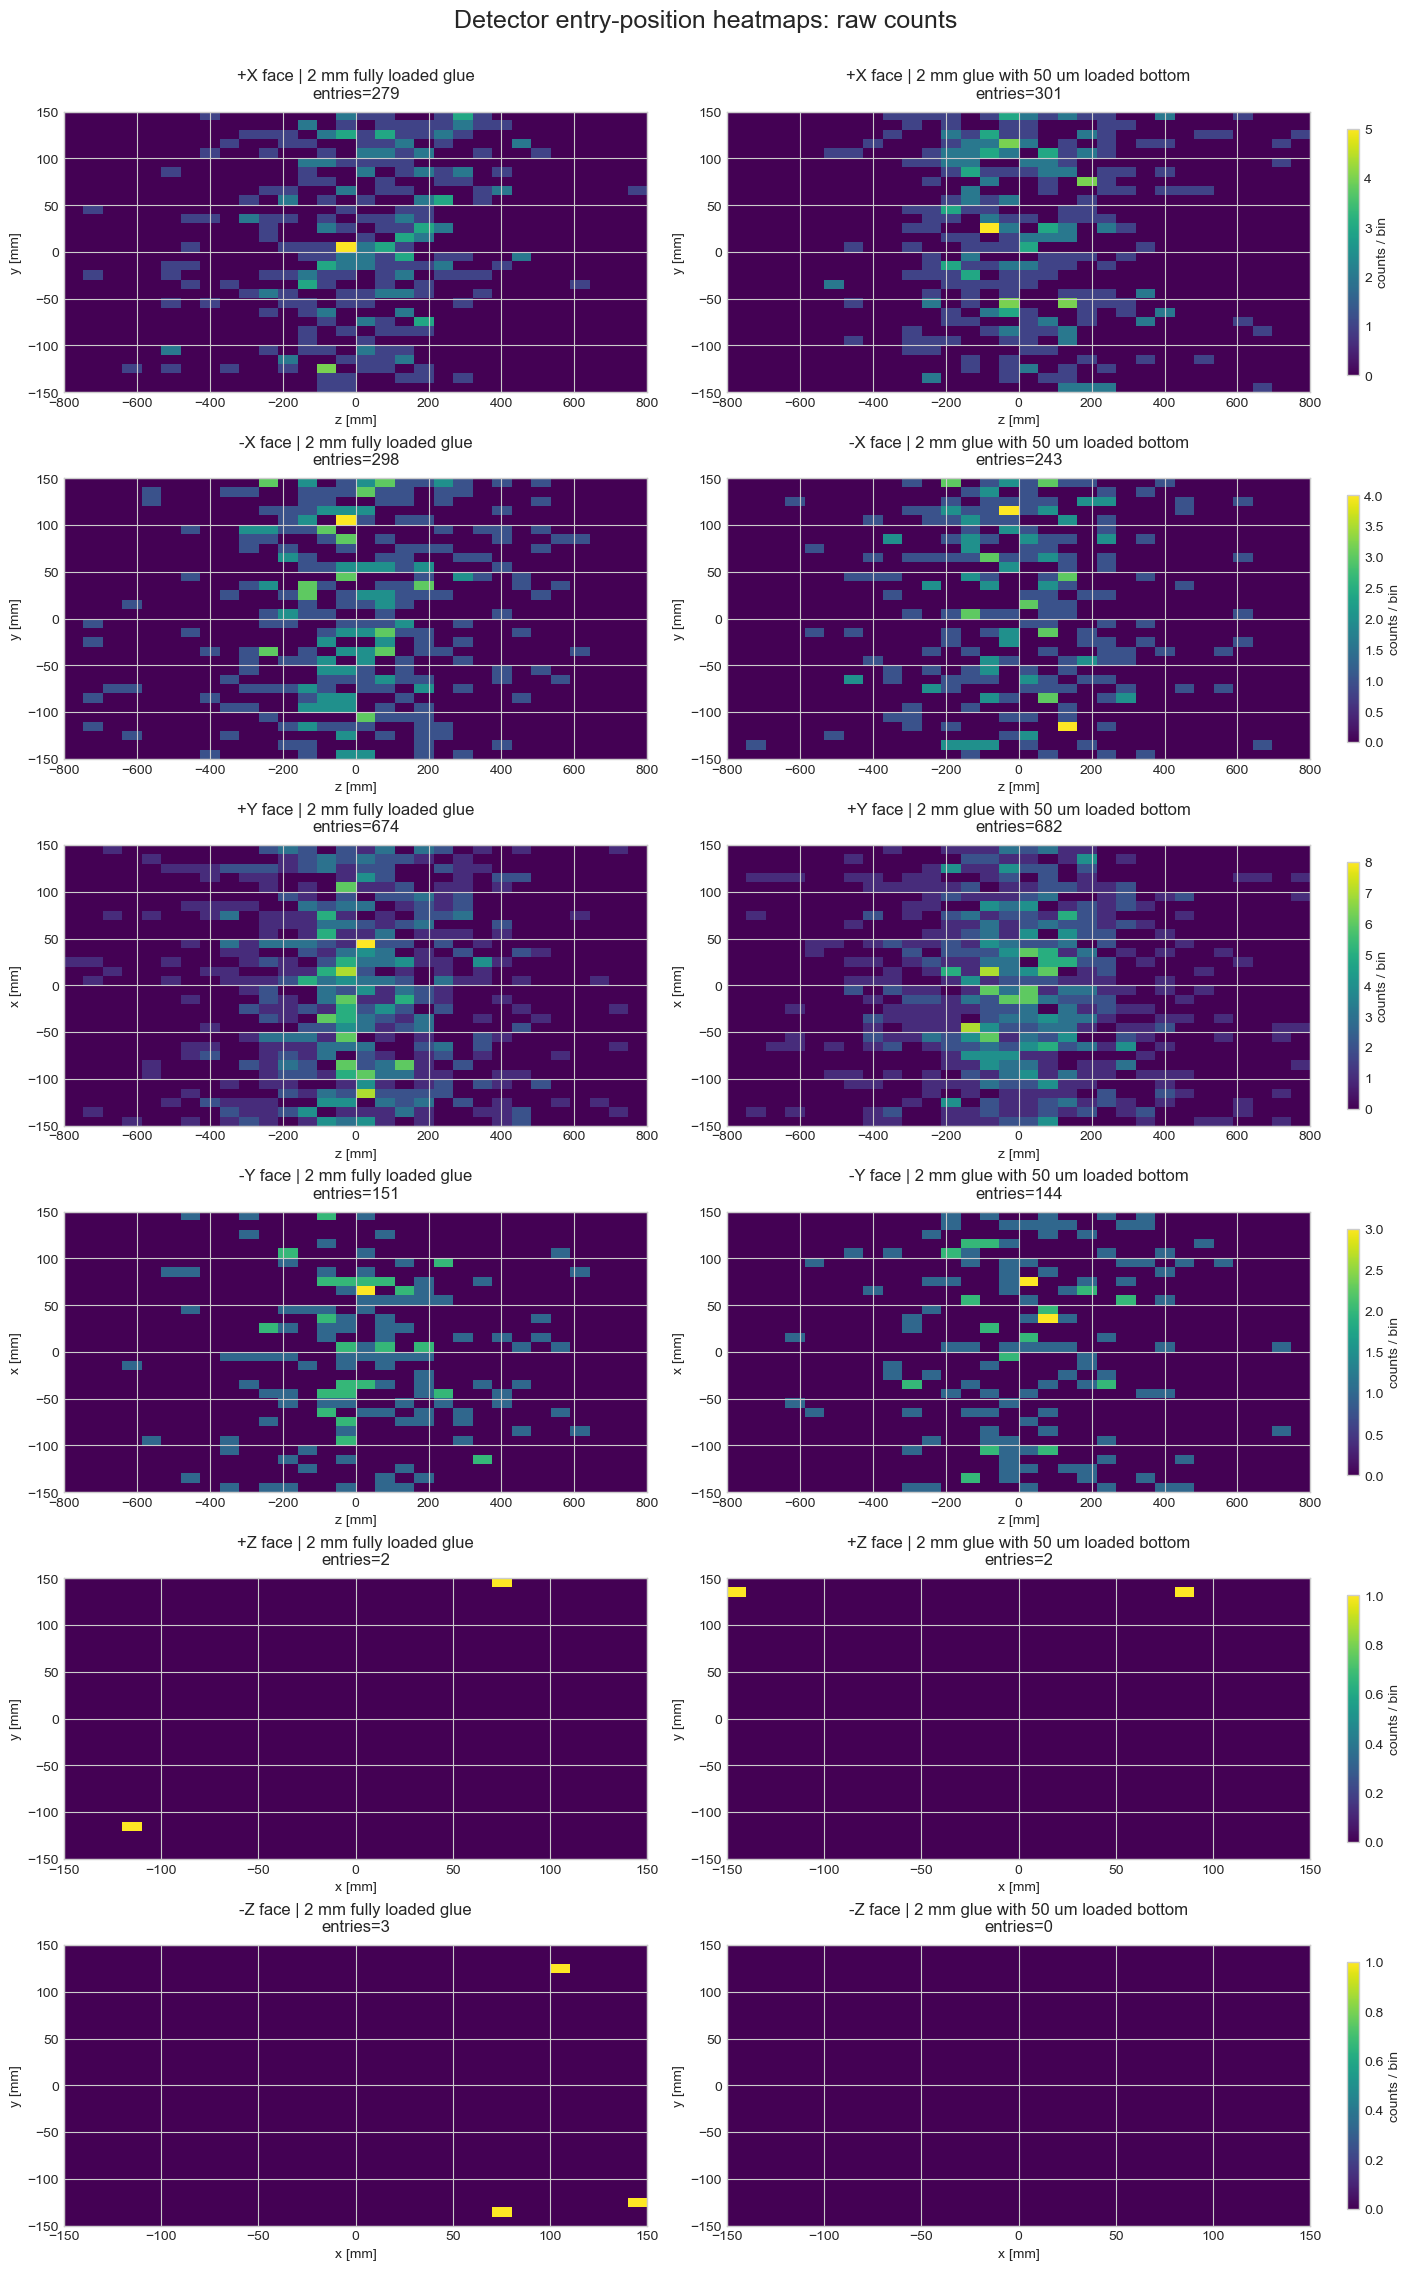

In [3]:
# Raw-count heatmaps with matched axes and matched color scales per face
bins = 30
fig, axes = plt.subplots(len(faces), len(dataset_stems), figsize=(14, 22), constrained_layout=True)

for row, face in enumerate(faces):
    xcol, ycol = face_axes[face]
    xlim, ylim = face_limits[face]
    face_histograms = []
    for stem in dataset_stems:
        face_df = detector_entries_by_dataset[stem]
        face_df = face_df[face_df['volumeName'] == face]
        hist, xedges, yedges = np.histogram2d(
            face_df[xcol],
            face_df[ycol],
            bins=bins,
            range=[xlim, ylim],
        )
        face_histograms.append((stem, hist.T, xedges, yedges, len(face_df)))

    vmax = max(hist.max() for _, hist, _, _, _ in face_histograms)
    norm = Normalize(vmin=0, vmax=vmax if vmax > 0 else 1)

    last_im = None
    for col, (stem, hist, xedges, yedges, n_hits) in enumerate(face_histograms):
        ax = axes[row, col]
        last_im = ax.imshow(
            hist,
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            origin='lower',
            aspect='auto',
            cmap='viridis',
            norm=norm,
        )
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(xcol.replace('_mm', ' [mm]'))
        ax.set_ylabel(ycol.replace('_mm', ' [mm]'))
        ax.set_title(f"{face_titles[face]} | {dataset_labels[stem]}\nentries={n_hits}", pad=10)
    fig.colorbar(last_im, ax=axes[row, :], shrink=0.88, pad=0.02, label='counts / bin')

fig.suptitle('Detector entry-position heatmaps: raw counts', fontsize=18, y=1.025)
plt.show()


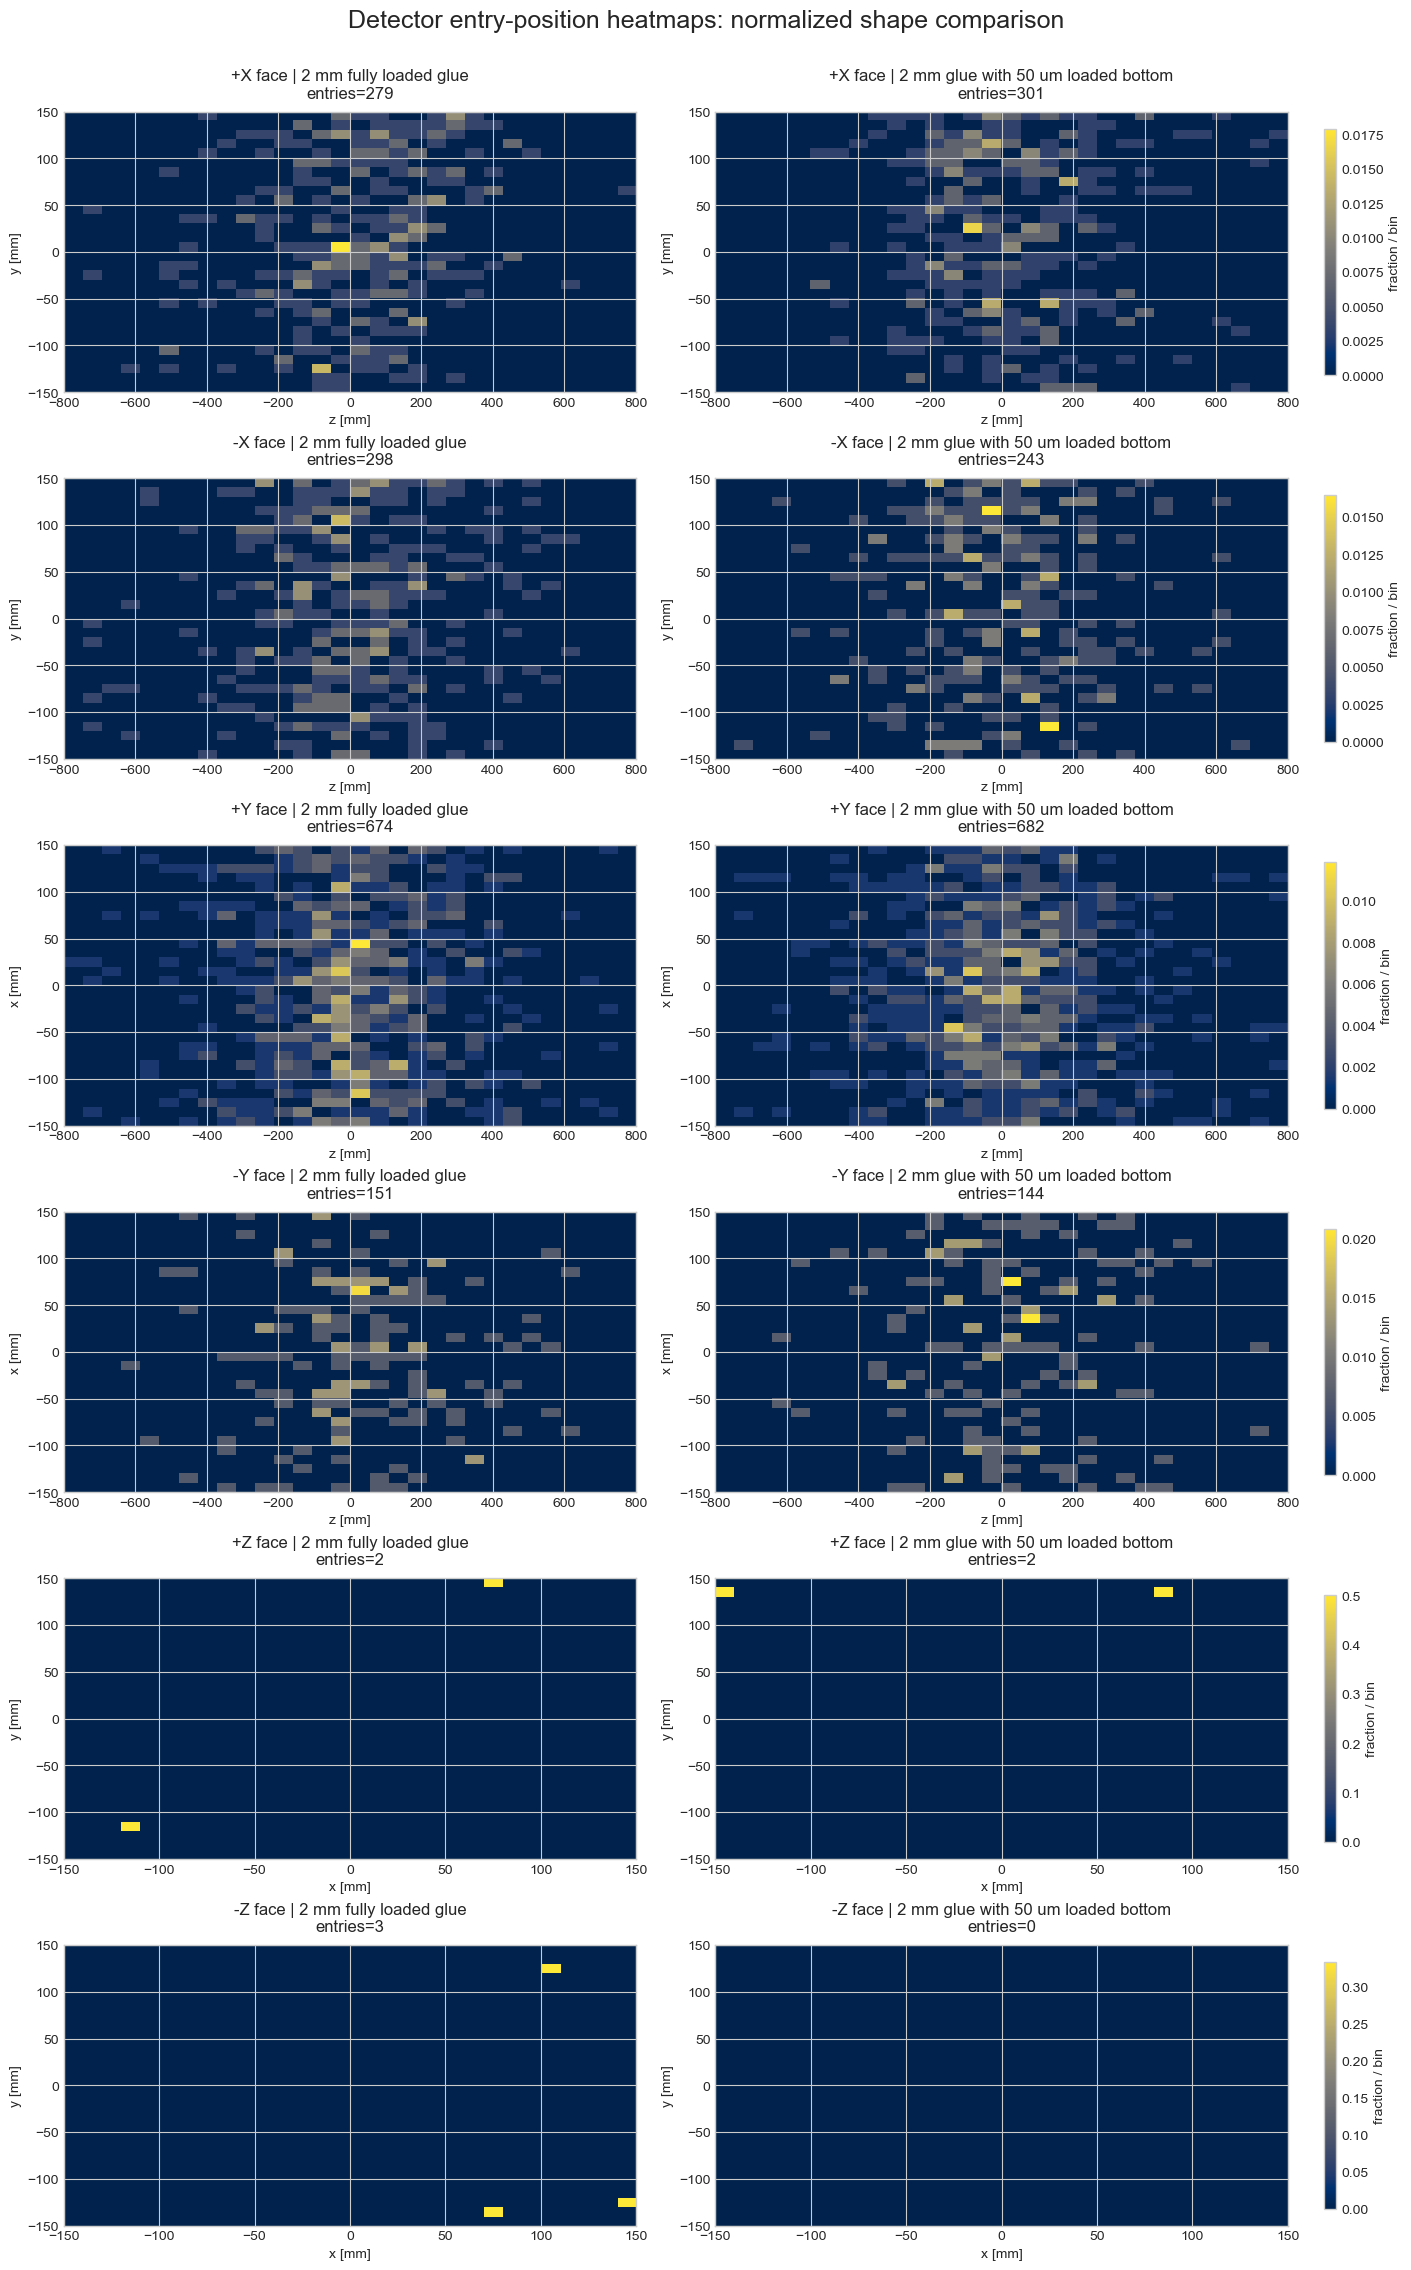

In [4]:
# Area-normalized heatmaps to compare spatial shape independent of total counts
bins = 30
fig, axes = plt.subplots(len(faces), len(dataset_stems), figsize=(14, 22), constrained_layout=True)

for row, face in enumerate(faces):
    xcol, ycol = face_axes[face]
    xlim, ylim = face_limits[face]
    face_histograms = []
    for stem in dataset_stems:
        face_df = detector_entries_by_dataset[stem]
        face_df = face_df[face_df['volumeName'] == face]
        hist, xedges, yedges = np.histogram2d(
            face_df[xcol],
            face_df[ycol],
            bins=bins,
            range=[xlim, ylim],
        )
        density = hist / hist.sum() if hist.sum() > 0 else hist
        face_histograms.append((stem, density.T, xedges, yedges, len(face_df)))

    vmax = max(hist.max() for _, hist, _, _, _ in face_histograms)
    norm = Normalize(vmin=0, vmax=vmax if vmax > 0 else 1)

    last_im = None
    for col, (stem, hist, xedges, yedges, n_hits) in enumerate(face_histograms):
        ax = axes[row, col]
        last_im = ax.imshow(
            hist,
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            origin='lower',
            aspect='auto',
            cmap='cividis',
            norm=norm,
        )
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(xcol.replace('_mm', ' [mm]'))
        ax.set_ylabel(ycol.replace('_mm', ' [mm]'))
        ax.set_title(f"{face_titles[face]} | {dataset_labels[stem]}\nentries={n_hits}", pad=10)
    fig.colorbar(last_im, ax=axes[row, :], shrink=0.88, pad=0.02, label='fraction / bin')

fig.suptitle('Detector entry-position heatmaps: normalized shape comparison', fontsize=18, y=1.025)
plt.show()


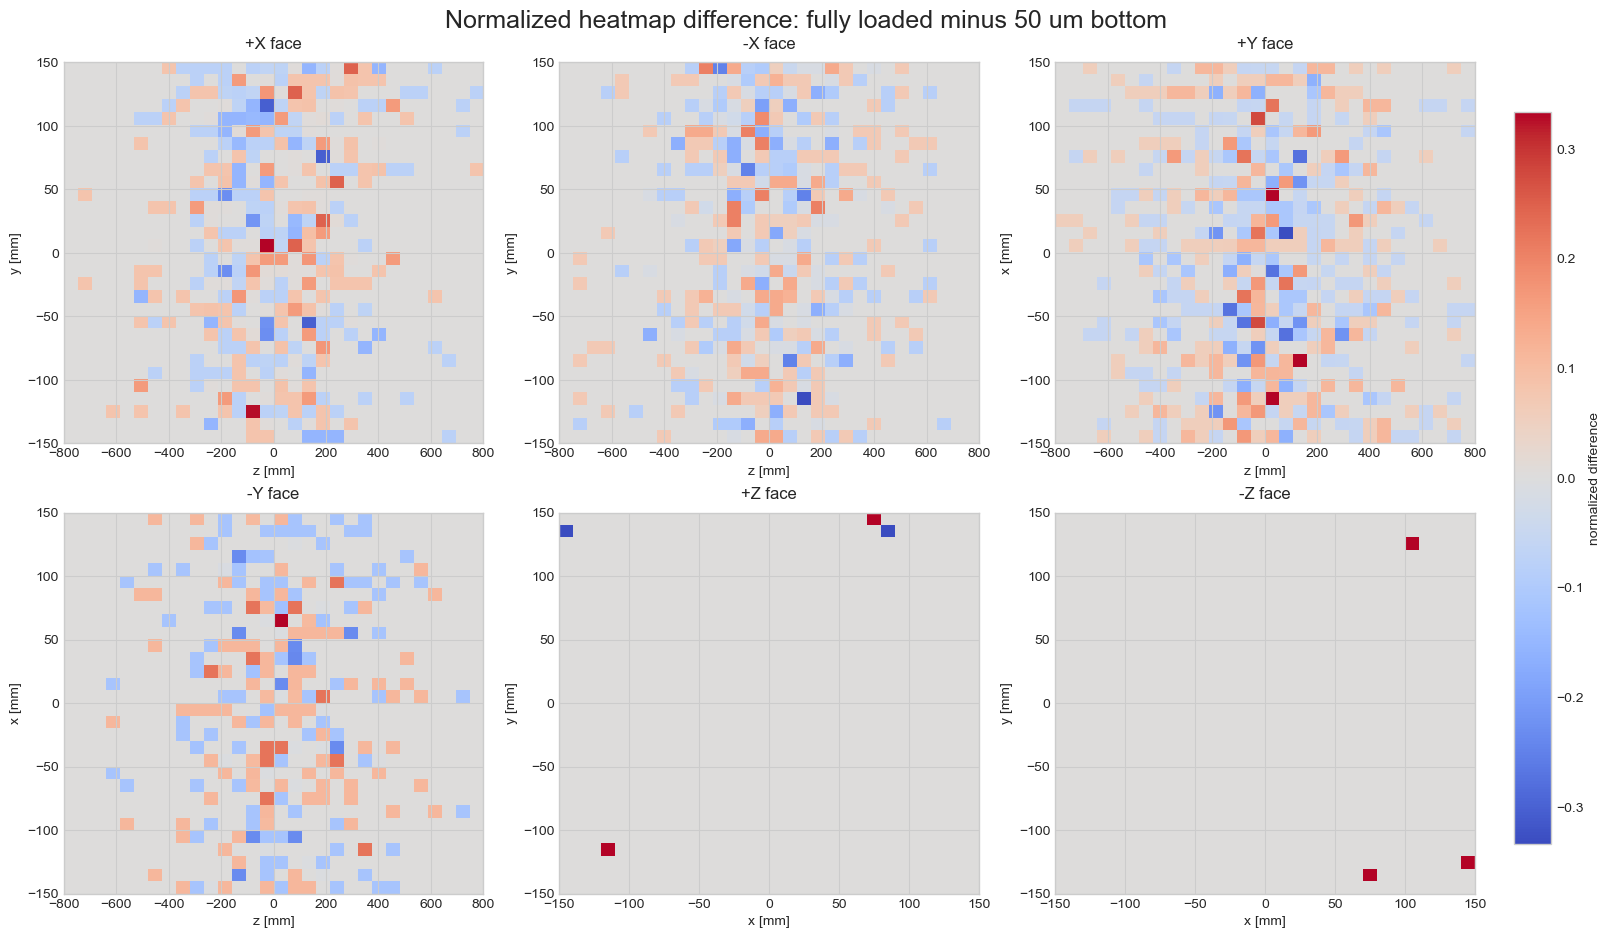

In [5]:
# Optional: normalized difference maps (fully loaded minus 50 um bottom)
bins = 30
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.flatten()

diff_images = []
for ax, face in zip(axes, faces):
    xcol, ycol = face_axes[face]
    xlim, ylim = face_limits[face]
    hists = {}
    for stem in dataset_stems:
        face_df = detector_entries_by_dataset[stem]
        face_df = face_df[face_df['volumeName'] == face]
        hist, xedges, yedges = np.histogram2d(
            face_df[xcol],
            face_df[ycol],
            bins=bins,
            range=[xlim, ylim],
        )
        hists[stem] = hist / hist.sum() if hist.sum() > 0 else hist
    diff = (hists['2mm_2mm_1k'] - hists['2mm_50um_bottom_1k']).T
    vmax = np.abs(diff).max()
    im = ax.imshow(
        diff,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        origin='lower',
        aspect='auto',
        cmap='coolwarm',
        vmin=-vmax if vmax > 0 else -1,
        vmax=vmax if vmax > 0 else 1,
    )
    diff_images.append(im)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(xcol.replace('_mm', ' [mm]'))
    ax.set_ylabel(ycol.replace('_mm', ' [mm]'))
    ax.set_title(face_titles[face], pad=10)

fig.colorbar(diff_images[-1], ax=axes, shrink=0.88, pad=0.02, label='normalized difference')
fig.suptitle('Normalized heatmap difference: fully loaded minus 50 um bottom', fontsize=18, y=1.025)
plt.show()
